Processing 0/152103...
Processing 10000/152103...
Processing 20000/152103...
Processing 30000/152103...
Processing 40000/152103...
Processing 50000/152103...
Processing 60000/152103...
Processing 70000/152103...
Processing 80000/152103...
Processing 90000/152103...
Processing 100000/152103...
Processing 110000/152103...
Processing 120000/152103...
Processing 130000/152103...
Processing 140000/152103...
Processing 150000/152103...
Saved diagnostic plot

Per-cluster summary:
Cluster    N        Brightness mean    Brightness std   Sobel mean     Sobel std
0          35807    0.4090             0.0757           0.0859         0.0187
1          34380    0.4099             0.0801           0.0890         0.0219
2          38523    0.4256             0.0798           0.0958         0.0257
3          43393    0.4354             0.0809           0.0736         0.0136


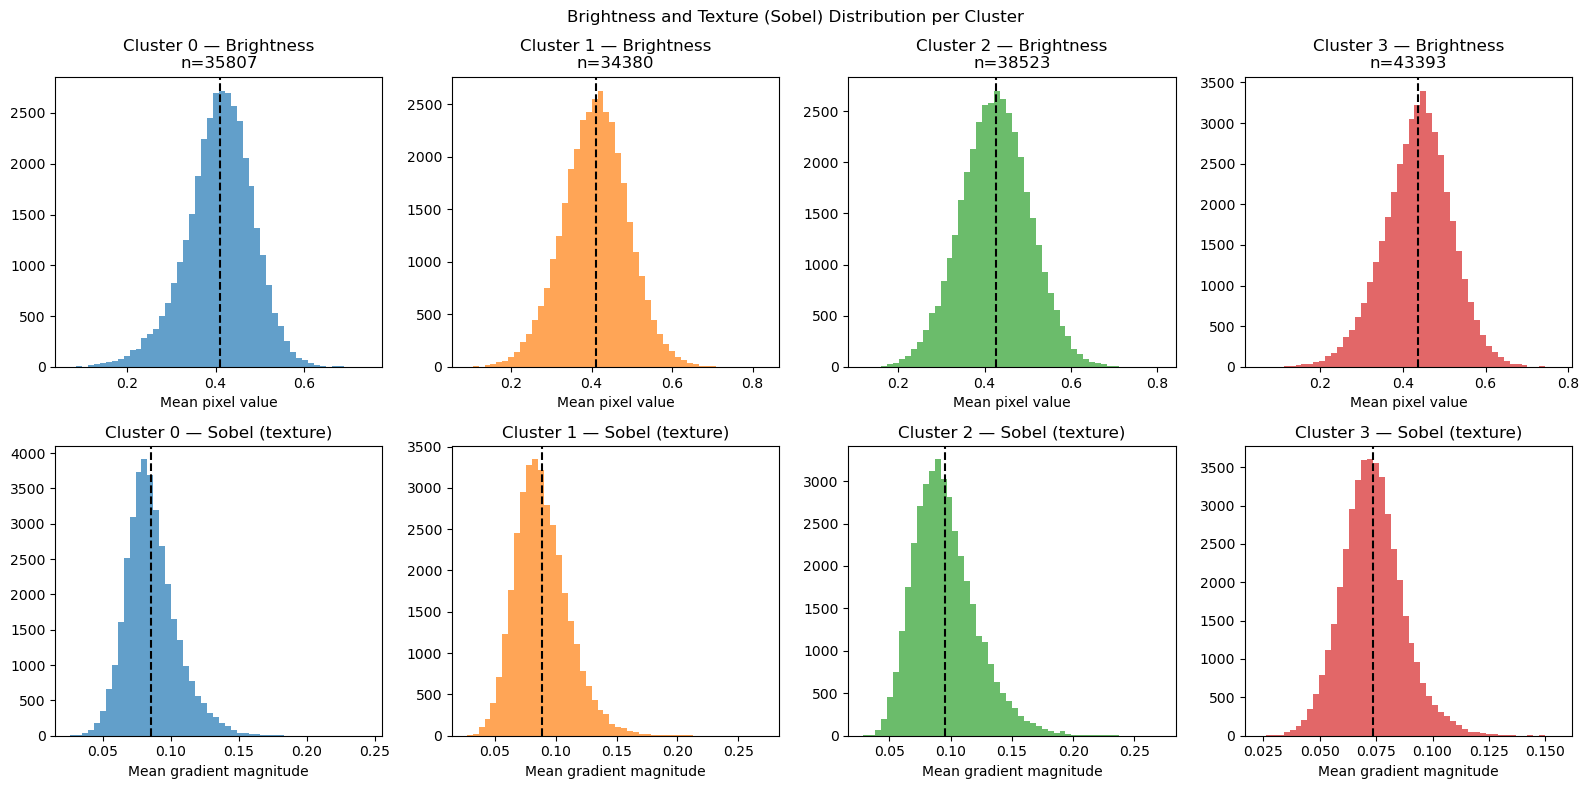

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import torchvision.transforms.functional as TF
import torch
import os

# ── constants ─────────────────────────────────────────────────────────────
EXTRACT_SIZE = 320
INPUT_SIZE   = 224

path = 'data/processed_wac_100m_new/sigma/100/craters.dat'
file_size = os.path.getsize(path)
N = file_size // (EXTRACT_SIZE * EXTRACT_SIZE * 1 * 4)
craters = np.memmap(path, dtype=np.float32, mode='r', shape=(N, 1, EXTRACT_SIZE, EXTRACT_SIZE))

latents = np.load('logs/mae/processed_wac_100m_new/100/3.0_10.0_50_mask0.75/models/latent_vectors.npy')
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
labels = KMeans(n_clusters=4, random_state=42).fit_predict(latents)

# Compute per-image stats in batches
batch_size = 1000
brightness = np.zeros(N)
sobel      = np.zeros(N)

for i in range(0, N, batch_size):
    if i % 10000 == 0:
        print(f"Processing {i}/{N}...")
    
    # load batch and center-crop to 224 — same as inference path
    raw   = torch.from_numpy(np.array(craters[i:i+batch_size, 0]))      # (B, 320, 320)
    batch = TF.center_crop(raw.unsqueeze(1), INPUT_SIZE).squeeze(1).numpy()  # (B, 224, 224)

    brightness[i:i+batch_size] = batch.mean(axis=(1, 2))

    for j, img in enumerate(batch):
        sx = ndimage.sobel(img, axis=0)
        sy = ndimage.sobel(img, axis=1)
        sobel[i+j] = np.sqrt(sx**2 + sy**2).mean()

# Plot histograms per cluster
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Brightness and Texture (Sobel) Distribution per Cluster')

for k in range(4):
    mask = labels == k

    axes[0, k].hist(brightness[mask], bins=50, color=f'C{k}', alpha=0.7)
    axes[0, k].set_title(f'Cluster {k} — Brightness\nn={mask.sum()}')
    axes[0, k].set_xlabel('Mean pixel value')
    axes[0, k].axvline(brightness[mask].mean(), color='black', linestyle='--')

    axes[1, k].hist(sobel[mask], bins=50, color=f'C{k}', alpha=0.7)
    axes[1, k].set_title(f'Cluster {k} — Sobel (texture)')
    axes[1, k].set_xlabel('Mean gradient magnitude')
    axes[1, k].axvline(sobel[mask].mean(), color='black', linestyle='--')

plt.tight_layout()
plt.savefig('cluster_brightness_texture_diagnostics.png', dpi=200)
print("Saved diagnostic plot")

print("\nPer-cluster summary:")
print(f"{'Cluster':<10} {'N':<8} {'Brightness mean':<18} {'Brightness std':<16} {'Sobel mean':<14} {'Sobel std'}")
for k in range(4):
    mask = labels == k
    print(f"{k:<10} {mask.sum():<8} {brightness[mask].mean():<18.4f} {brightness[mask].std():<16.4f} "
          f"{sobel[mask].mean():<14.4f} {sobel[mask].std():.4f}")

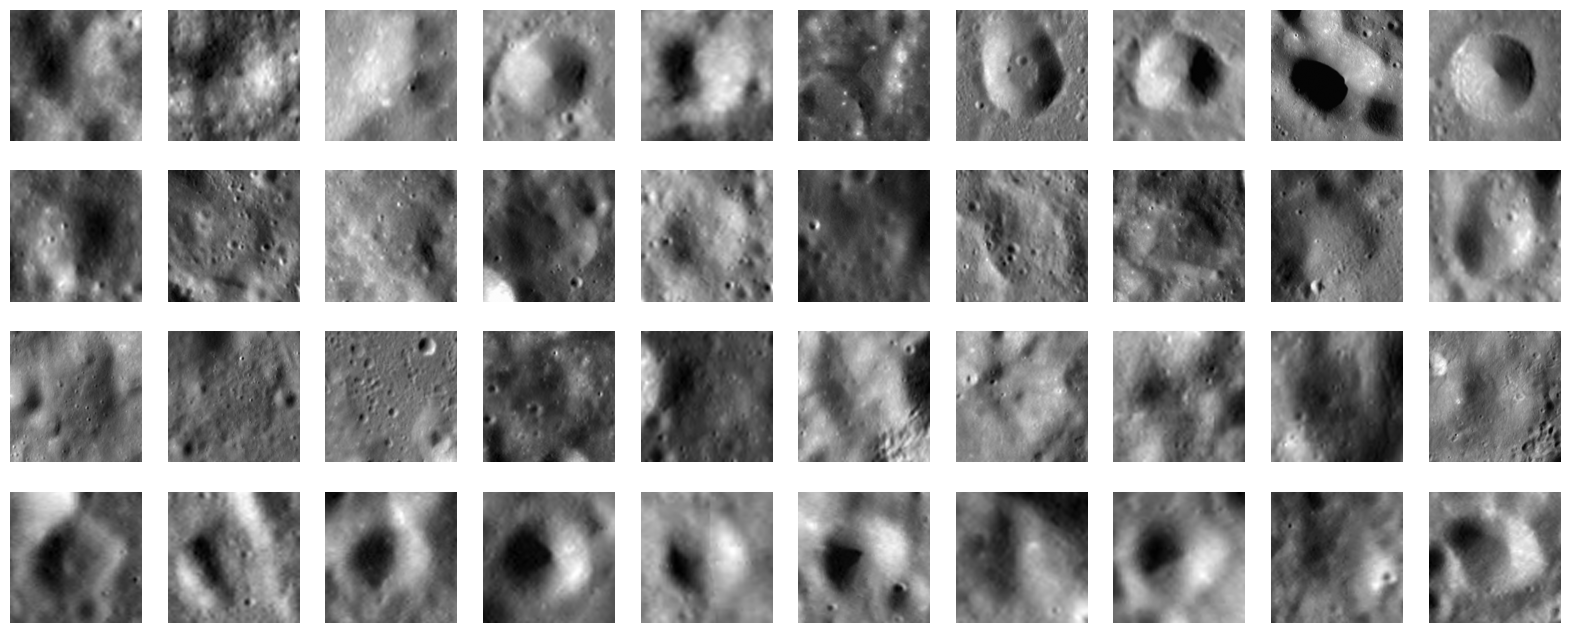

In [3]:
fig, axes = plt.subplots(4, 10, figsize=(20, 8))
for k in range(4):
    mask = np.where(labels == k)[0]
    samples = np.random.choice(mask, size=10, replace=False)
    for j, idx in enumerate(samples):
        axes[k, j].imshow(craters[idx, 0], cmap='gray')
        axes[k, j].axis('off')
    axes[k, 0].set_ylabel(f'Cluster {k}', fontsize=12)
plt.savefig('cluster_examples.png', dpi=200)

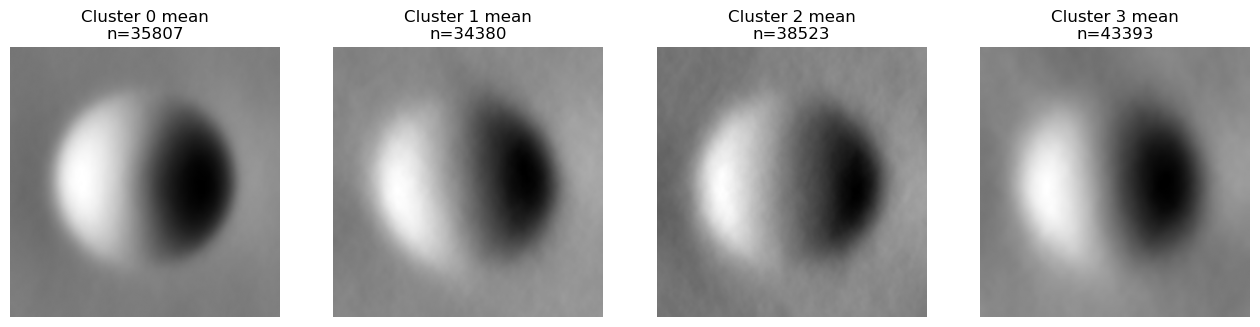

In [4]:
# Visualize mean image per cluster

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for k in range(4):
    mask = np.where(labels == k)[0]
    mean_img = np.array(craters[mask[:500], 0]).mean(axis=0)
    axes[k].imshow(mean_img, cmap='gray')
    axes[k].set_title(f'Cluster {k} mean\nn={mask.shape[0]}')
    axes[k].axis('off')
plt.savefig('cluster_mean_images.png', dpi=200)

NameError: name 'latents_pca' is not defined

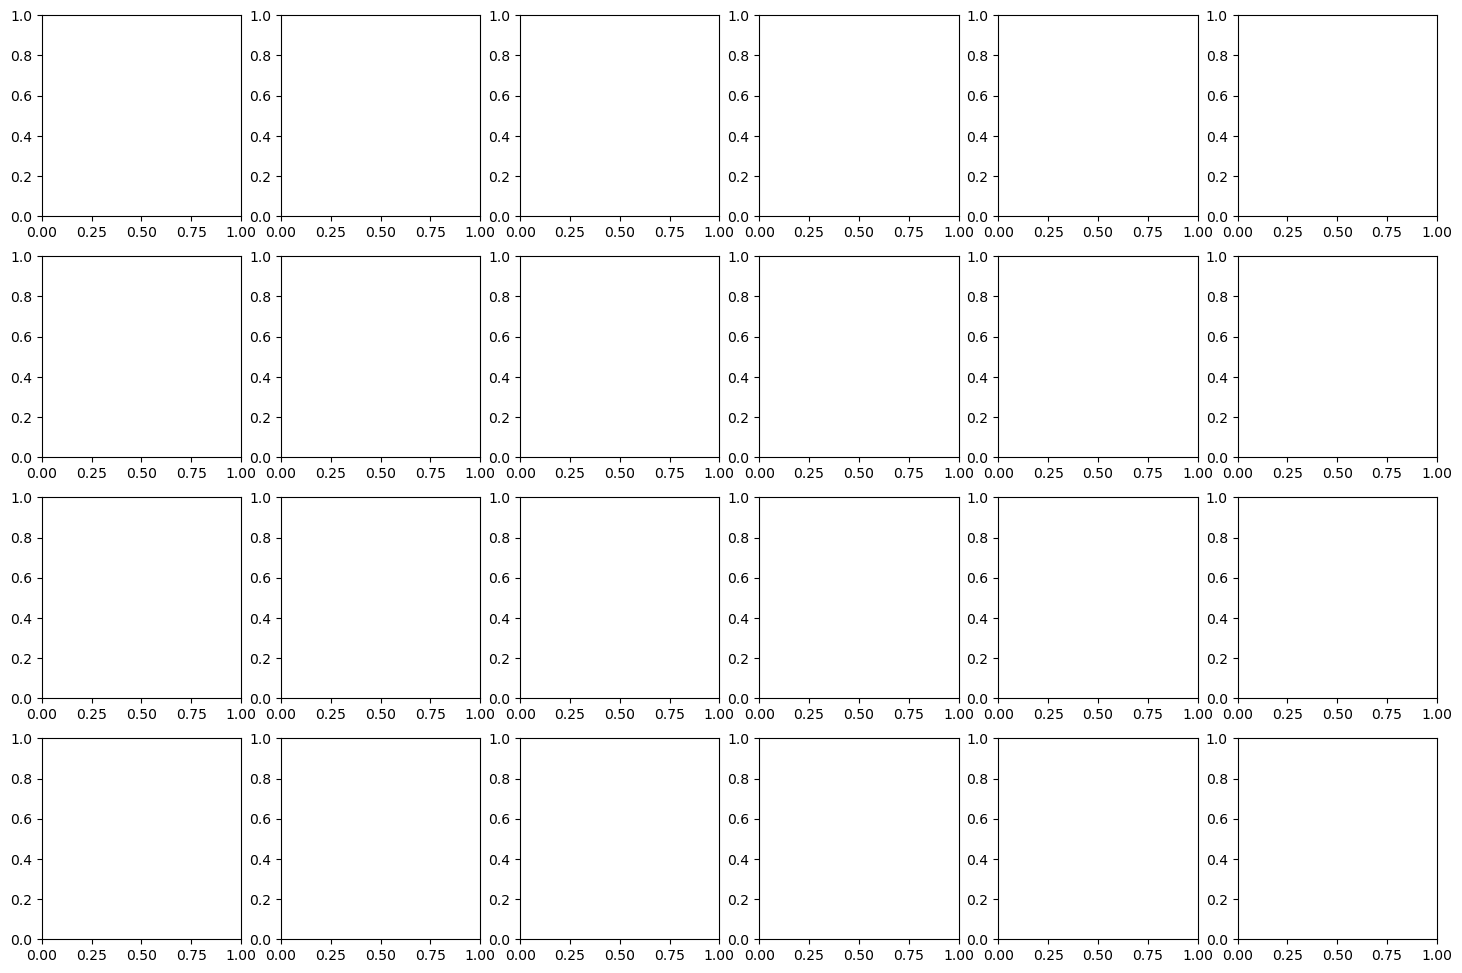

In [5]:
from sklearn.metrics import pairwise_distances_argmin_min

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
#kmeans = KMeans(n_clusters=4, random_state=42).fit(latents_pca)

for k in range(4):
    mask = np.where(labels == k)[0]
    cluster_latents = latents_pca[mask]
    center = kmeans.cluster_centers_[k]
    
    # Distance from center
    dists = np.linalg.norm(cluster_latents - center, axis=1)
    
    # 3 closest to center (most typical)
    closest = mask[np.argsort(dists)[:3]]
    # 3 furthest from center (outliers)
    furthest = mask[np.argsort(dists)[-3:]]
    
    for j, idx in enumerate(closest):
        axes[k, j].imshow(craters[idx, 0], cmap='gray')
        axes[k, j].set_title('typical', fontsize=8)
        axes[k, j].axis('off')
    for j, idx in enumerate(furthest):
        axes[k, j+3].imshow(craters[idx, 0], cmap='gray')
        axes[k, j+3].set_title('outlier', fontsize=8)
        axes[k, j+3].axis('off')
    axes[k, 0].set_ylabel(f'Cluster {k}', fontsize=11)

plt.tight_layout()
plt.savefig('cluster_archetypes.png', dpi=200)

In [7]:
from scipy.stats import pearsonr
import pandas as pd

metadata = pd.read_csv('data/processed_wac_100m_new/sigma/100/metadata.csv')  # x, y, diam, lat, lon

properties = {
    'brightness': brightness,
    'sobel': sobel,
    'log_diameter': np.log(metadata['diam'].values),
    'latitude': metadata['lat'].values,
}

print(f"\nPearson correlation of top 10 PCA components with image properties:")
print(f"{'Property':<15}", end='')
for i in range(10):
    print(f"  PC{i+1:>2}", end='')
print()

pca_coords = pca.transform(latents)
for name, prop in properties.items():
    print(f"{name:<15}", end='')
    for i in range(10):
        r, _ = pearsonr(pca_coords[:, i], prop)
        print(f"  {r:>5.2f}", end='')
    print()


Pearson correlation of top 10 PCA components with image properties:
Property         PC 1  PC 2  PC 3  PC 4  PC 5  PC 6  PC 7  PC 8  PC 9  PC10


NameError: name 'pca' is not defined

In [ ]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import ndimage
from scipy.stats import pearsonr
import pandas as pd
import os

# --- Paths ---
latents_path = 'logs/mae/processed_wac_100m_new/100/3.0_10.0_300_mask0.75/models/latent_vectors.npy'
craters_path = 'data/processed_wac_100m_new/sigma/100/craters.dat'
metadata_path = 'data/processed_wac_100m_new/sigma/100/metadata.csv'
pca_path = 'logs/mae/processed_wac_100m_new/100/3.0_10.0_300_mask0.75/pca_model.pkl'
kmeans_path = 'logs/mae/processed_wac_100m_new/100/3.0_10.0_300_mask0.75/kmeans_model.pkl'
out_dir = 'logs/mae/processed_wac_100m_new/100/3.0_10.0_300_mask0.75'

In [ ]:
# --- Load latents ---
latents = np.load(latents_path)
print(f"Latents shape: {latents.shape}")

# --- PCA ---
pca = PCA(n_components=0.95, random_state=42)
latents_pca = pca.fit_transform(latents)
joblib.dump(pca, pca_path)
print("Fitted and saved new PCA model")

for i, v in enumerate(pca.explained_variance_ratio_[:10]):
    print(f"PC{i+1}: {v*100:.1f}%")

# --- KMeans ---
if os.path.exists(kmeans_path):
    kmeans = joblib.load(kmeans_path)
    labels = kmeans.predict(latents)
    print("Loaded existing KMeans model")
else:
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    labels = kmeans.fit_predict(latents)
    joblib.dump(kmeans, kmeans_path)
    print("Fitted and saved new KMeans model")
print(f"Label distribution: { {k: (labels==k).sum() for k in range(4)} }")


# --- Remap cluster labels: swap 1 and 2 to match deformation sequence 0→2→1→3 ---
remap = {0: 0, 1: 2, 2: 1, 3: 3}
labels = np.array([remap[l] for l in labels])

# Update KMeans cluster centers to match new labeling
kmeans.cluster_centers_[[1, 2]] = kmeans.cluster_centers_[[2, 1]]

print(f"Label distribution after remap: { {k: (labels==k).sum() for k in range(4)} }")



Latents shape: (152103, 64)
Fitted and saved new PCA model
PC1: 32.4%
PC2: 27.6%
PC3: 23.2%
PC4: 5.8%
PC5: 3.6%
PC6: 2.7%
PC7: 2.0%
PC8: 1.1%
PC9: 0.4%
PC10: 0.3%
Loaded existing KMeans model
Label distribution: {0: np.int64(35807), 1: np.int64(34380), 2: np.int64(38523), 3: np.int64(43393)}
Label distribution after remap: {0: np.int64(35807), 1: np.int64(38523), 2: np.int64(34380), 3: np.int64(43393)}


In [9]:
# --- Load craters ---
file_size = os.path.getsize(craters_path)
N = file_size // (320 * 320 * 1 * 4)
craters = np.memmap(craters_path, dtype=np.float32, mode='r', shape=(N, 1, 320, 320))


Generating Plot 1: Mean images...


IndexError: boolean index did not match indexed array along axis 0; size of axis is 310414 but size of corresponding boolean axis is 152103

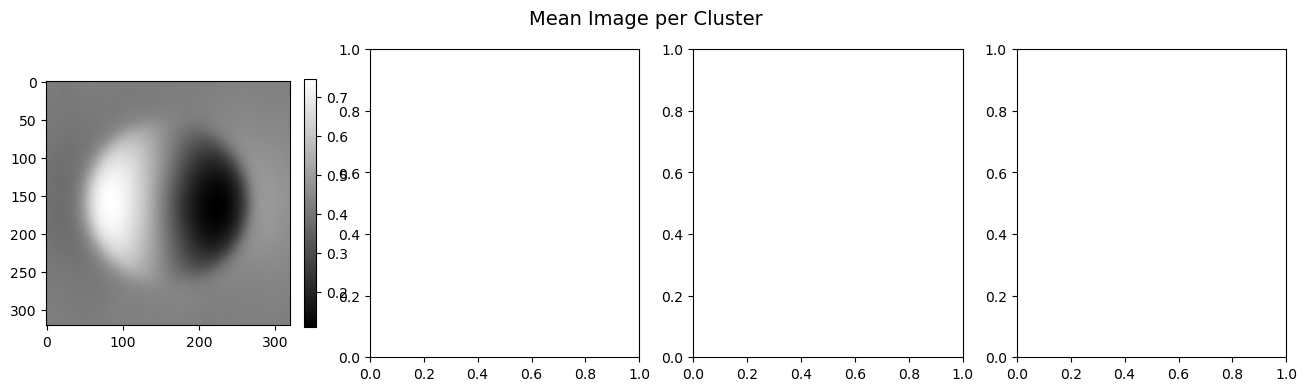

In [10]:
# --- Plot 1: Mean image per cluster ---
print("\nGenerating Plot 1: Mean images...")
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Mean Image per Cluster', fontsize=14)

for k in range(4):
    mask = np.where(labels == k)[0]
    sample = mask[:2000]
    mean_img = np.array(craters[sample, 0]).mean(axis=0)
    im = axes[k].imshow(mean_img, cmap='gray')
    plt.colorbar(im, ax=axes[k], fraction=0.046)
    axes[k].set_title(f'Cluster {k}\nn={mask.shape[0]}\nSobel={sobel[labels==k].mean():.4f}')
    axes[k].axis('off')

plt.tight_layout()
plt.savefig(f'{out_dir}/cluster_mean_images.png', dpi=200)
plt.show()
plt.close()
print("Saved cluster_mean_images.png")


Generating Plot 1: Mean images...


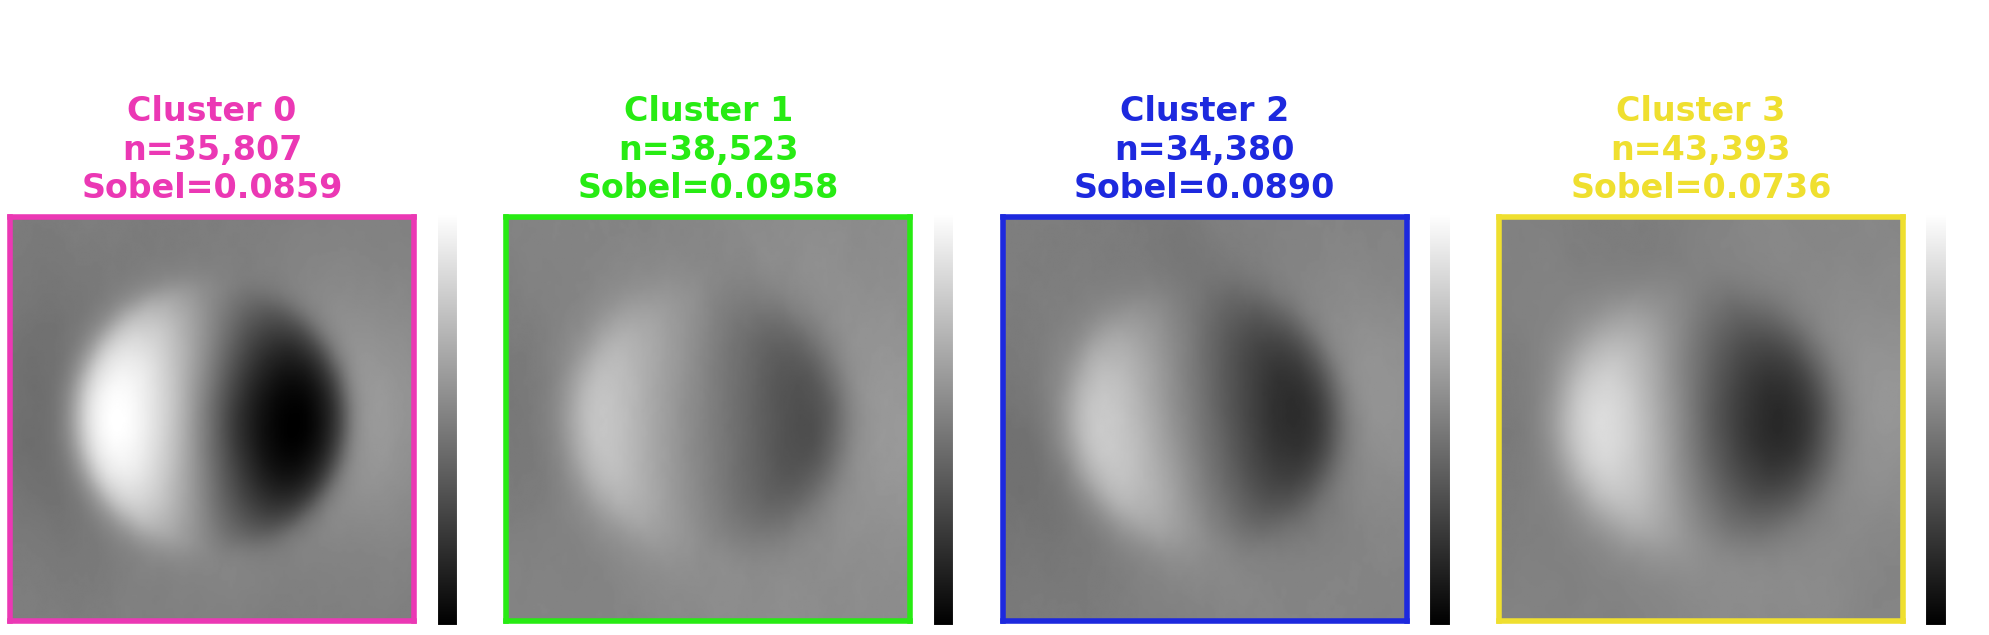

Saved cluster_mean_images_presentation.png


In [16]:
# --- Plot 1: Mean image per cluster ---
print("\nGenerating Plot 1: Mean images...")

CLUSTER_COLORS = {
    0: '#EB38B4',  # magenta
    2: '#1D29DE',  # blue
    1: '#27EB13',  # green
    3: '#EFDF2F',  # yellow
}

# Display order: 0, 1, 2, 3
DISPLAY_ORDER = [0, 1, 2, 3]

# Compute all mean images first
mean_imgs = {}
for k in range(4):
    mask = np.where(labels == k)[0]
    sample = mask[:2000]
    mean_imgs[k] = np.array(craters[sample, 0]).mean(axis=0)

# Shared scale across all clusters for fair comparison
vmin = min(img.min() for img in mean_imgs.values())
vmax = max(img.max() for img in mean_imgs.values())

fig, axes = plt.subplots(1, 4, figsize=(20, 7))

# Fully transparent background
fig.patch.set_alpha(0)

fig.suptitle('Average Crater per Cluster',
             fontsize=32, fontweight='bold', color='white', y=1.04)

for col_idx, k in enumerate(DISPLAY_ORDER):
    color = CLUSTER_COLORS[k]
    ax = axes[col_idx]

    # Transparent background
    ax.set_facecolor('none')
    ax.patch.set_alpha(0)

    im = ax.imshow(mean_imgs[k], cmap='gray', vmin=vmin, vmax=vmax)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046)
    cbar.ax.yaxis.set_tick_params(color='white', labelsize=11)
    cbar.outline.set_edgecolor('white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white', fontsize=11)

    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(
        f'Cluster {k}\nn={np.sum(labels==k):,}\nSobel={sobel[labels==k].mean():.4f}',
        fontsize=24, fontweight='bold', color=color, pad=14
    )

plt.tight_layout()
plt.savefig(f'{out_dir}/cluster_mean_images_presentation.png',
            dpi=200, bbox_inches='tight', transparent=True)
plt.show()
plt.close()
print("Saved cluster_mean_images_presentation.png")

Generating Plot 2: Examples per cluster...


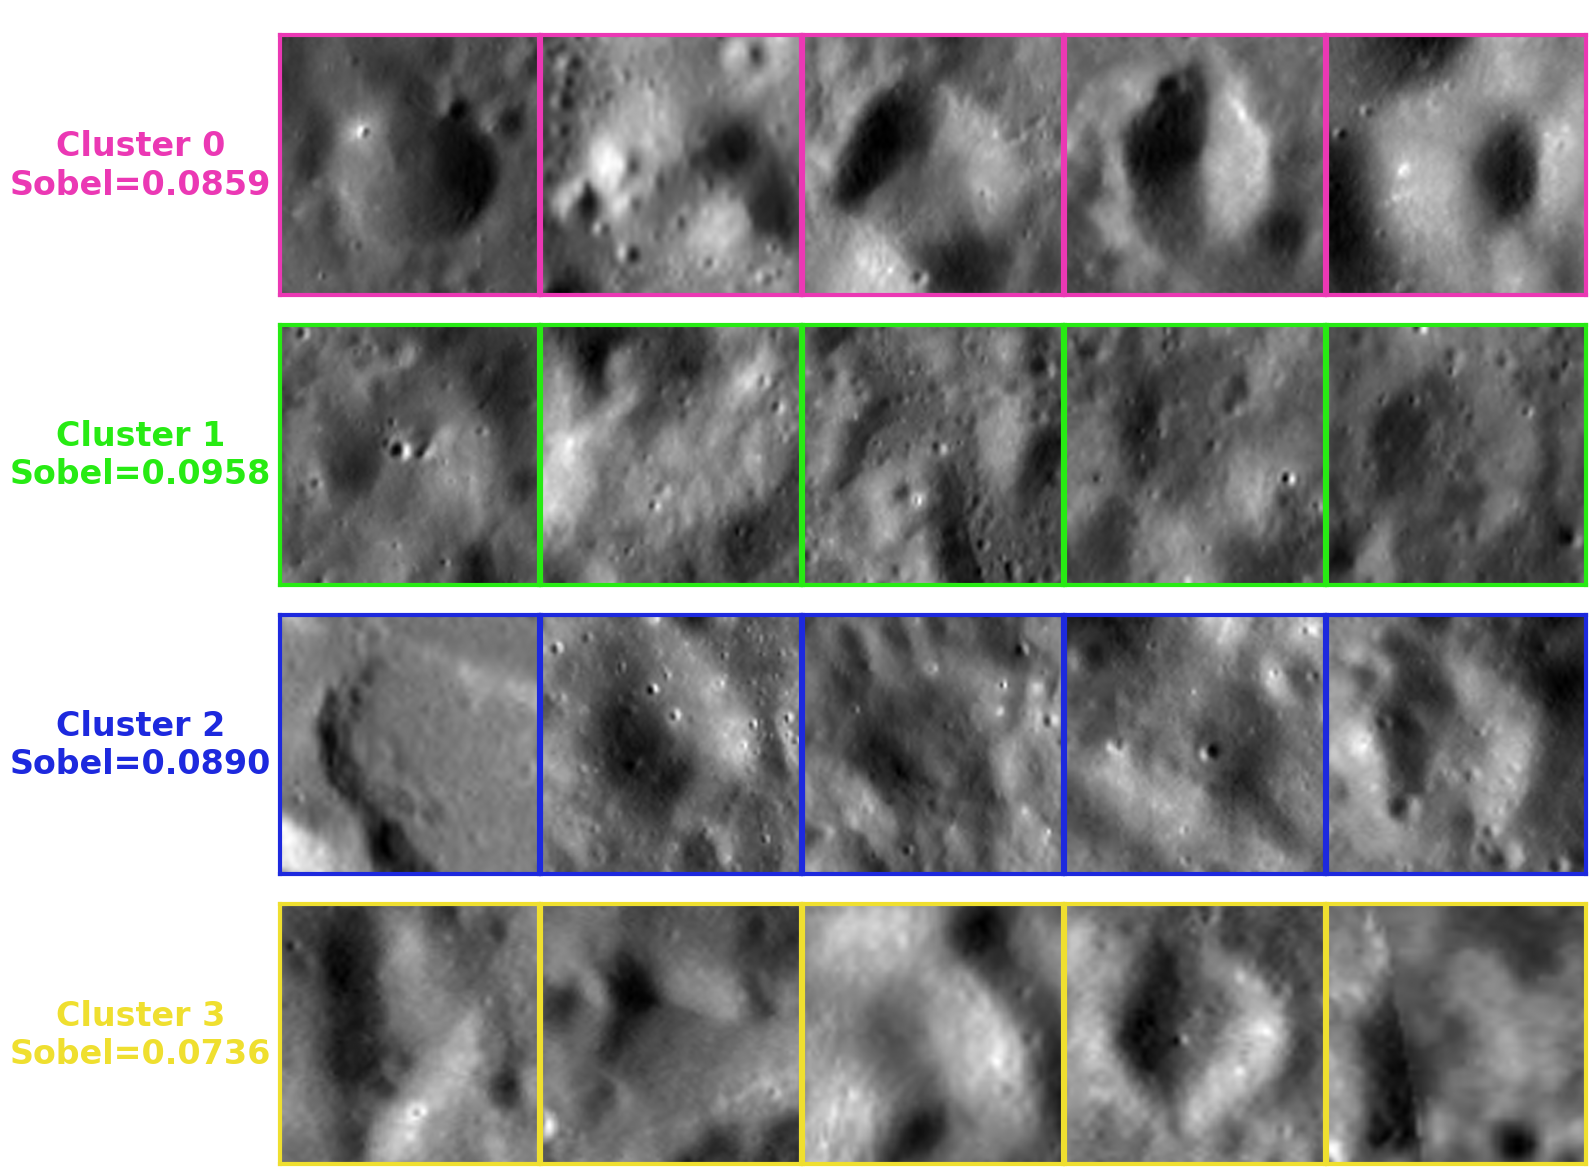

Saved cluster_central_examples_presentation.png


In [17]:
# --- Plot 2: 5 most central examples per cluster ---
print("Generating Plot 2: Examples per cluster...")

CLUSTER_LABELS = {
    0: f'Cluster 0\nSobel={sobel[labels==0].mean():.4f}',
    1: f'Cluster 1\nSobel={sobel[labels==1].mean():.4f}',
    2: f'Cluster 2\nSobel={sobel[labels==2].mean():.4f}',
    3: f'Cluster 3\nSobel={sobel[labels==3].mean():.4f}',
}

# Display order: 0, 2, 1, 3
DISPLAY_ORDER = [0, 1, 2, 3]

fig, axes = plt.subplots(4, 5, figsize=(16, 12))

# Fully transparent background
fig.patch.set_alpha(0)

for row_idx, k in enumerate(DISPLAY_ORDER):
    mask = np.where(labels == k)[0]
    cluster_latents = latents[mask]
    center = kmeans.cluster_centers_[k]
    dists = np.linalg.norm(cluster_latents - center, axis=1)
    closest = mask[np.argsort(dists)[:5]]
    color = CLUSTER_COLORS[k]

    for j, idx in enumerate(closest):
        ax = axes[row_idx, j]
        ax.imshow(craters[idx, 0], cmap='gray',
                  vmin=craters[idx, 0].min(), vmax=craters[idx, 0].max())

        # Transparent axis background
        ax.set_facecolor('none')
        ax.patch.set_alpha(0)

        # Colored border matching cluster color
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        # Column header on first row only
        if row_idx == 0:
            ax.set_title(f'Example {j+1}', fontsize=14,
                         color='white', pad=8, fontweight='bold')

    # Row label with cluster color
    axes[row_idx, 0].set_ylabel(CLUSTER_LABELS[k], fontsize=24,
                                 color=color, fontweight='bold',
                                 rotation=0, labelpad=100, va='center')

plt.tight_layout()
plt.savefig(f'{out_dir}/cluster_central_examples_presentation.png',
            dpi=200, bbox_inches='tight', transparent=True)
plt.show()
plt.close()
print("Saved cluster_central_examples_presentation.png")

Generating Plot 3: Brightness and Sobel histograms...


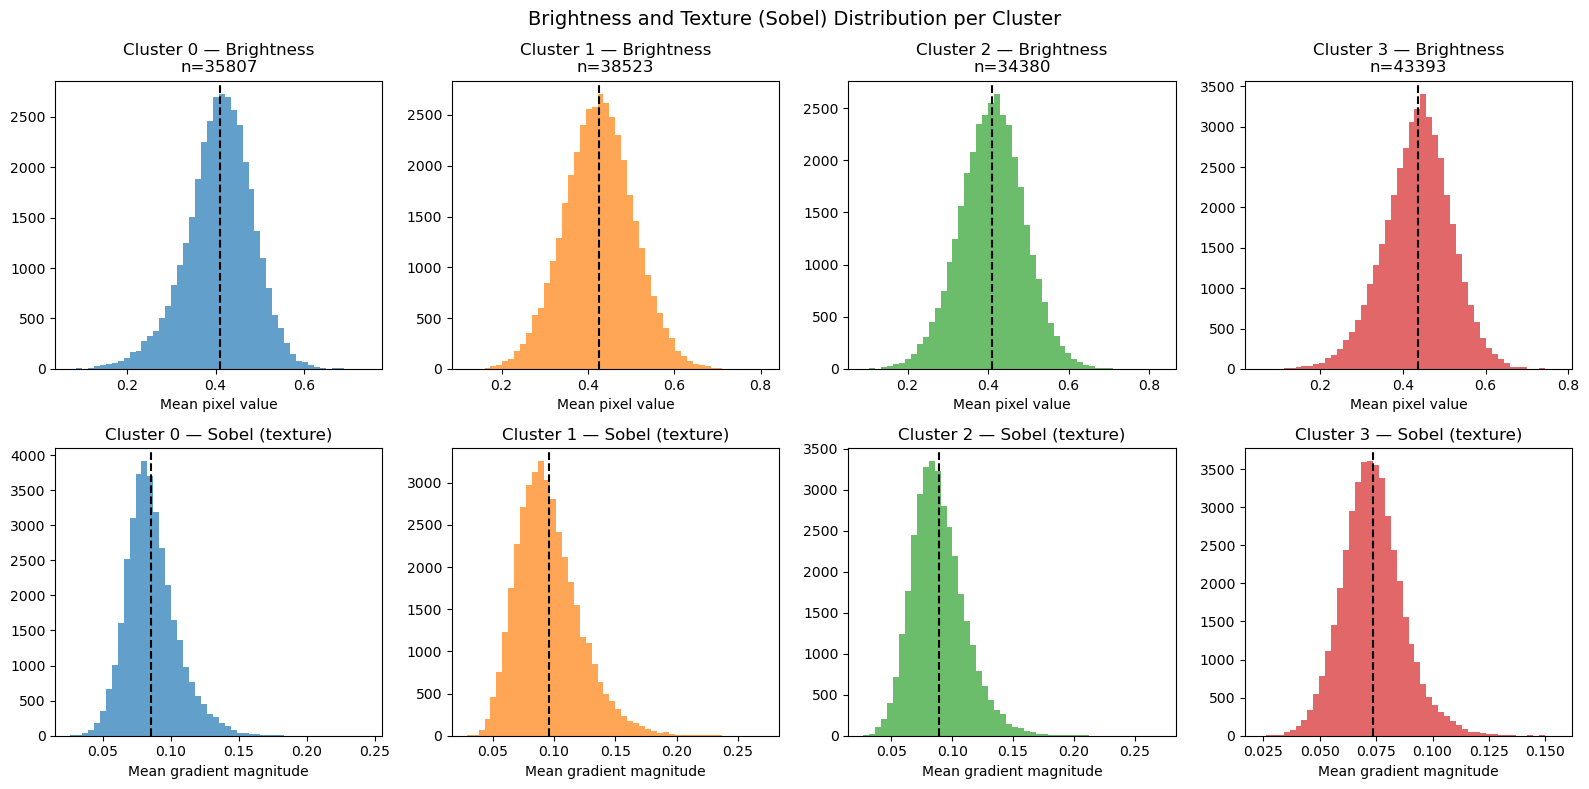

Saved cluster_brightness_texture_diagnostics.png


In [18]:
# --- Plot 3: Brightness and Sobel histograms per cluster ---
print("Generating Plot 3: Brightness and Sobel histograms...")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Brightness and Texture (Sobel) Distribution per Cluster', fontsize=14)

for k in range(4):
    mask = labels == k
    axes[0, k].hist(brightness[mask], bins=50, color=f'C{k}', alpha=0.7)
    axes[0, k].set_title(f'Cluster {k} — Brightness\nn={mask.sum()}')
    axes[0, k].set_xlabel('Mean pixel value')
    axes[0, k].axvline(brightness[mask].mean(), color='black', linestyle='--')

    axes[1, k].hist(sobel[mask], bins=50, color=f'C{k}', alpha=0.7)
    axes[1, k].set_title(f'Cluster {k} — Sobel (texture)')
    axes[1, k].set_xlabel('Mean gradient magnitude')
    axes[1, k].axvline(sobel[mask].mean(), color='black', linestyle='--')

plt.tight_layout()
plt.savefig(f'{out_dir}/cluster_brightness_texture_diagnostics.png', dpi=200)
plt.show()
plt.close()
print("Saved cluster_brightness_texture_diagnostics.png")

Generating Plot 3: Brightness and Sobel histograms...


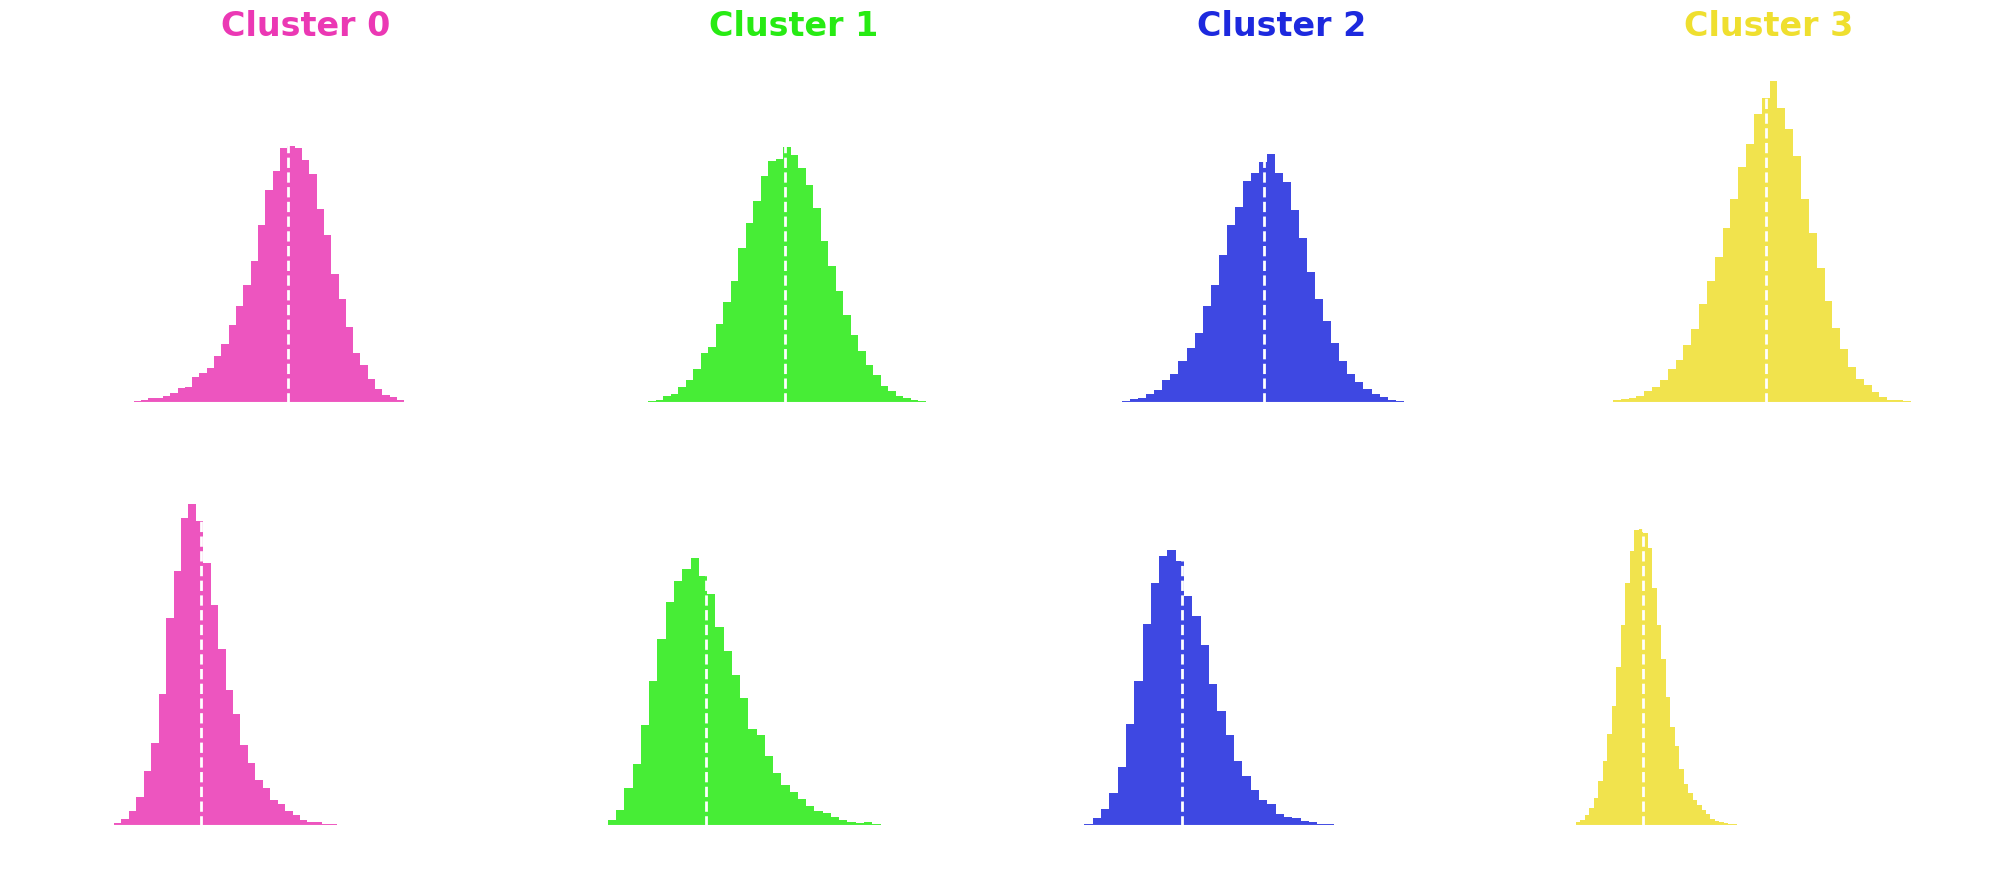

Saved cluster_brightness_texture_presentation.png


In [19]:
# --- Plot 3: Brightness and Sobel histograms per cluster ---
print("Generating Plot 3: Brightness and Sobel histograms...")

brightness_xmin = brightness.min()
brightness_xmax = brightness.max()
sobel_xmin = sobel.min()
sobel_xmax = sobel.max()

brightness_ymax = max(np.histogram(brightness[labels==k], bins=50)[0].max() for k in range(4))
sobel_ymax = max(np.histogram(sobel[labels==k], bins=50)[0].max() for k in range(4))

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

# Fully transparent figure and axes backgrounds
fig.patch.set_alpha(0)

for k in range(4):
    mask = labels == k
    color = CLUSTER_COLORS[k]

    # --- Row 0: Brightness ---
    ax0 = axes[0, k]
    ax0.set_facecolor('none')
    ax0.patch.set_alpha(0)

    ax0.hist(brightness[mask], bins=50, color=color, alpha=0.85, edgecolor='none')
    ax0.axvline(brightness[mask].mean(), color='white', linestyle='--', linewidth=2,
                label=f'mean={brightness[mask].mean():.4f}')
    ax0.set_xlim(brightness_xmin, brightness_xmax)
    ax0.set_ylim(0, brightness_ymax * 1.1)
    ax0.set_title(f'Cluster {k}',
                  fontsize=24, fontweight='bold', color=color, pad=10)

    if k == 0:
        ax0.set_ylabel('Brightness', fontsize=15, color='white', fontweight='bold', labelpad=10)
    ax0.set_xlabel('Mean pixel value', fontsize=13, color='white', labelpad=6)

    ax0.tick_params(colors='white', labelsize=11, width=1.5, length=5)
    for spine in ['bottom', 'left']:
        ax0.spines[spine].set_color('white')
        ax0.spines[spine].set_linewidth(1.5)
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)

    ax0.legend(fontsize=10, labelcolor='white', framealpha=0)

    # --- Row 1: Sobel ---
    ax1 = axes[1, k]
    ax1.set_facecolor('none')
    ax1.patch.set_alpha(0)

    ax1.hist(sobel[mask], bins=50, color=color, alpha=0.85, edgecolor='none')
    ax1.axvline(sobel[mask].mean(), color='white', linestyle='--', linewidth=2,
                label=f'mean={sobel[mask].mean():.4f}')
    ax1.set_xlim(sobel_xmin, sobel_xmax)
    ax1.set_ylim(0, sobel_ymax * 1.1)

    if k == 0:
        ax1.set_ylabel('Sobel (texture)', fontsize=15, color='white', fontweight='bold', labelpad=10)
    ax1.set_xlabel('Mean gradient magnitude', fontsize=13, color='white', labelpad=6)

    ax1.tick_params(colors='white', labelsize=11, width=1.5, length=5)
    for spine in ['bottom', 'left']:
        ax1.spines[spine].set_color('white')
        ax1.spines[spine].set_linewidth(1.5)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    ax1.legend(fontsize=10, labelcolor='white', framealpha=0)

plt.tight_layout()
plt.savefig(f'{out_dir}/cluster_brightness_texture_presentation.png',
            dpi=200, bbox_inches='tight', transparent=True)
plt.show()
plt.close()
print("Saved cluster_brightness_texture_presentation.png")

Generating Plot 4: Archetype grid...


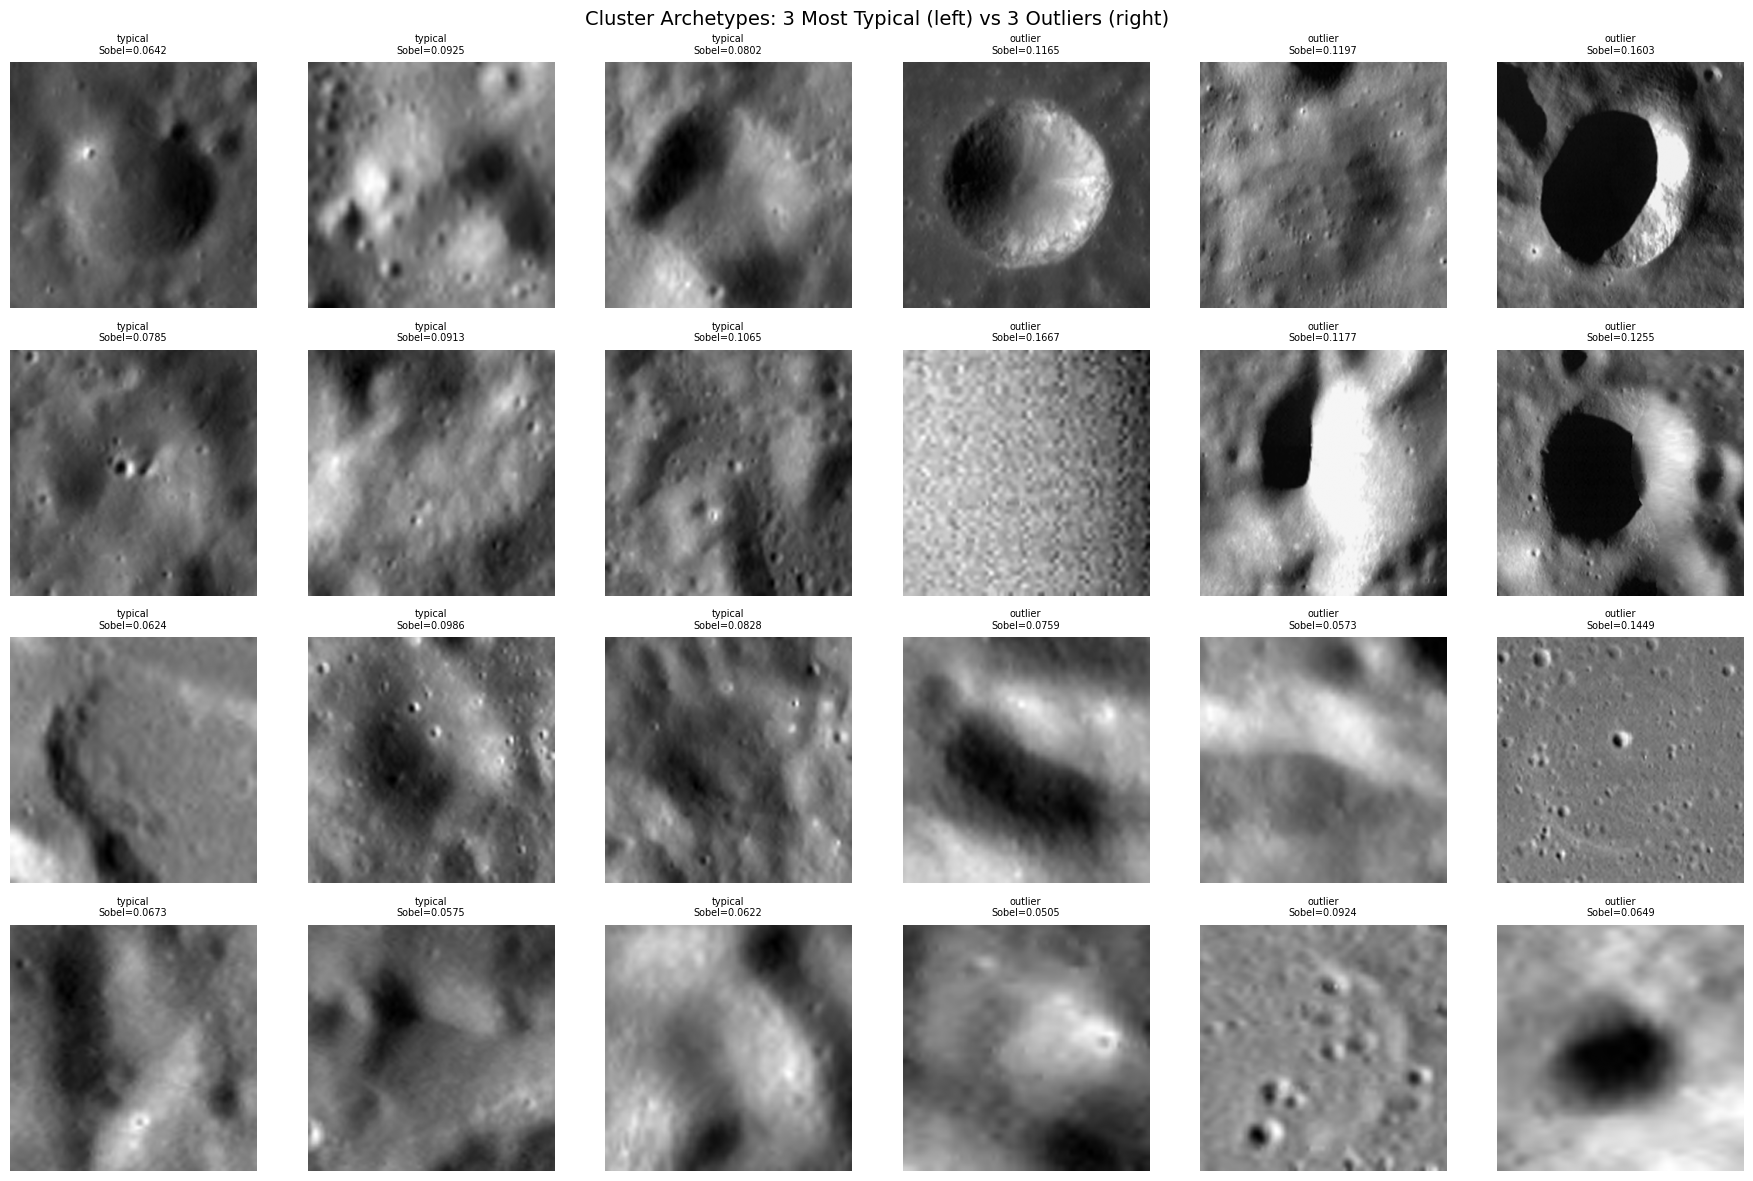

Saved cluster_archetype_grid.png


In [20]:
# --- Plot 4: Archetype grid (closest/furthest from cluster center) ---
print("Generating Plot 4: Archetype grid...")
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle('Cluster Archetypes: 3 Most Typical (left) vs 3 Outliers (right)', fontsize=14)

for k in range(4):
    mask = np.where(labels == k)[0]
    cluster_latents = latents[mask]
    center = kmeans.cluster_centers_[k]
    dists = np.linalg.norm(cluster_latents - center, axis=1)

    closest = mask[np.argsort(dists)[:3]]
    furthest = mask[np.argsort(dists)[-3:]]

    for j, idx in enumerate(closest):
        axes[k, j].imshow(craters[idx, 0], cmap='gray')
        axes[k, j].set_title(f'typical\nSobel={sobel[idx]:.4f}', fontsize=7)
        axes[k, j].axis('off')
    for j, idx in enumerate(furthest):
        axes[k, j+3].imshow(craters[idx, 0], cmap='gray')
        axes[k, j+3].set_title(f'outlier\nSobel={sobel[idx]:.4f}', fontsize=7)
        axes[k, j+3].axis('off')
    axes[k, 0].set_ylabel(f'Cluster {k}\nn={mask.shape[0]}', fontsize=11)

plt.tight_layout()
plt.savefig(f'{out_dir}/cluster_archetype_grid.png', dpi=200)
plt.show()
plt.close()
print("Saved cluster_archetype_grid.png")

In [17]:
# --- Plot 5: Pearson correlation heatmap ---
print("Generating Plot 5: Pearson correlation heatmap...")
metadata = pd.read_csv(metadata_path)

properties = {
    'brightness': brightness,
    'sobel': sobel,
    'log_diameter': np.log(metadata['diam'].values),
    'latitude': metadata['lat'].values,
}

n_pcs = 10
corr_matrix = np.zeros((len(properties), n_pcs))
pca_coords = pca.transform(latents)

print(f"\nPearson correlation of top {n_pcs} PCA components with image properties:")
print(f"{'Property':<15}", end='')
for i in range(n_pcs):
    print(f"  PC{i+1:>2}", end='')
print()

for row_idx, (name, prop) in enumerate(properties.items()):
    print(f"{name:<15}", end='')
    for i in range(n_pcs):
        r, _ = pearsonr(pca_coords[:, i], prop)
        corr_matrix[row_idx, i] = r
        print(f"  {r:>5.2f}", end='')
    print()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')

ax.set_xticks(range(n_pcs))
ax.set_xticklabels([f'PC{i+1}' for i in range(n_pcs)])
ax.set_yticks(range(len(properties)))
ax.set_yticklabels(list(properties.keys()))
ax.set_title('Pearson Correlation: Image Properties vs PCA Components')

for i in range(len(properties)):
    for j in range(n_pcs):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black')

plt.tight_layout()
plt.savefig(f'{out_dir}/pca_correlation_heatmap.png', dpi=200)
plt.close()
print("Saved pca_correlation_heatmap.png")

print("\nAll plots saved to", out_dir)

Generating Plot 5: Pearson correlation heatmap...

Pearson correlation of top 10 PCA components with image properties:
Property         PC 1  PC 2  PC 3  PC 4  PC 5  PC 6  PC 7  PC 8  PC 9  PC10
brightness        0.14  -0.14   0.72  -0.49   0.24   0.08  -0.28   0.04   0.05   0.03
sobel             0.76  -0.79   0.01  -0.16  -0.23   0.03   0.10   0.09  -0.01  -0.04
log_diameter      0.36  -0.39   0.05  -0.06  -0.25  -0.00   0.12   0.09  -0.15  -0.03
latitude          0.13  -0.12  -0.13  -0.09   0.07  -0.03  -0.04  -0.05  -0.06  -0.17
Saved pca_correlation_heatmap.png

All plots saved to logs/mae/processed_wac_100m_new/sigma/100


In [28]:
# --- Save Clustering Info ---
from sympy import Point
import geopandas as gpd


coords = metadata[['x', 'y']].values

df = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "cluster": labels
})
df.to_csv(f'{out_dir}/geo_map_clusters.csv', index=False)
print(f"Saved crater clusters to {out_dir}/geo_map_clusters.csv. You can now overlay in GIS.")

# --- GeoDataFrame & GeoJSON ---
geometry = [Point(xy) for xy in coords]
gdf = gpd.GeoDataFrame({'cluster': labels}, geometry=geometry)
gdf.to_file(f'{out_dir}/geo_map_clusters.geojson', driver="GeoJSON")
print(f"GeoJSON with clusters saved to: {out_dir}/geo_map_clusters.geojson")

Saved crater clusters to logs/mae/processed_wac_100m_new/sigma/100/geo_map_clusters.csv. You can now overlay in GIS.


KeyboardInterrupt: 

Selected crater: ID=02-1-000081  Lat=58.54  Lon=240.80  Diam=9.8 km


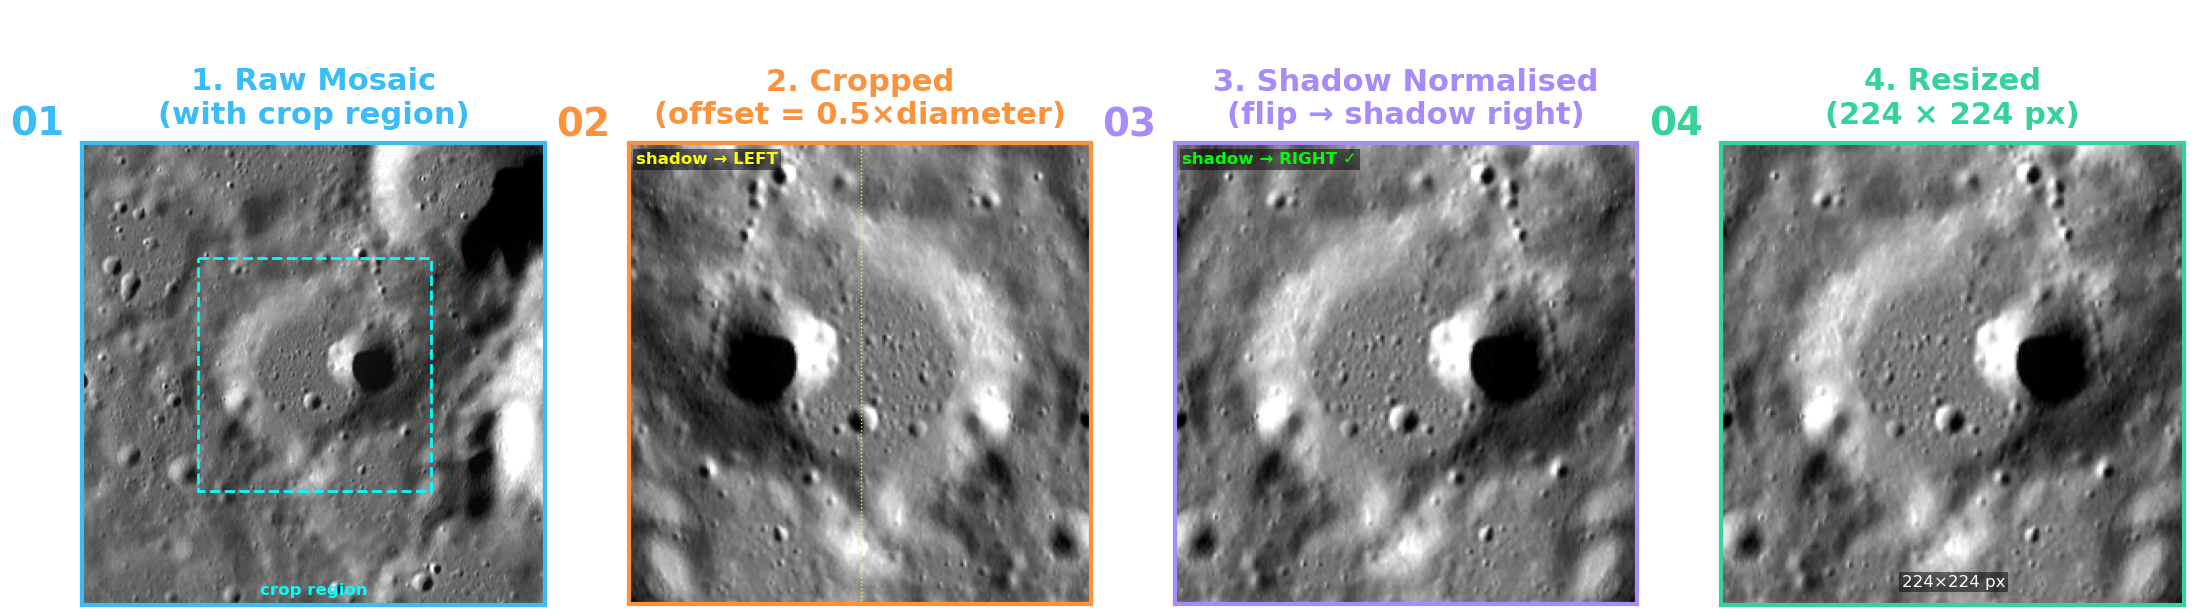

Saved: crater_preprocessing_pipeline.png


In [7]:
import numpy as np
import pandas as pd
import pyproj
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from src.helper_functions import crop_crater

# ── Config ──────────────────────────────────────────────────────────────────
MAP_FILE     = "data/raw/wac_mosaic_new_version/sigma/100/highpass_filtered_lunar_mosaic.tif"   # ← update
CRATERS_CSV  = "data/raw/lunar_crater_database_robbins_2018.csv"    # ← update
OFFSET       = 0.5
TARGET_SIZE  = 224

# ── CRS ─────────────────────────────────────────────────────────────────────
def get_craters_crs():
    wkt = """
        GEOGCS["GCS_Moon",
        DATUM["D_Moon_2000",
        SPHEROID["Moon_2000_IAU_IAG",1737400,0,LENGTHUNIT["metre",1]]],
        PRIMEM["Reference_Meridian",0],
        UNIT["metre",1]],
        PROJECTION["Equirectangular"],
        PARAMETER["standard_parallel_1",0],
        PARAMETER["central_meridian",0],
        PARAMETER["false_easting",0],
        PARAMETER["false_northing",0],
        UNIT["metre",1,AUTHORITY["EPSG","9001"]],
        AXIS["Easting",EAST],
        AXIS["Northing",NORTH],
        AUTHORITY["ESRI","103881"]]
    """
    return pyproj.CRS.from_wkt(wkt)

# ── Pick one ~10 km crater ───────────────────────────────────────────────────
craters = pd.read_csv(CRATERS_CSV)
candidate = craters[
    (craters['DIAM_CIRC_IMG'] >= 9.5) &
    (craters['DIAM_CIRC_IMG'] <= 10.0) &
    (craters['LAT_CIRC_IMG']  >= -60) &
    (craters['LAT_CIRC_IMG']  <=  60)
].iloc[2]

print(f"Selected crater: ID={candidate['CRATER_ID']}  "
      f"Lat={candidate['LAT_CIRC_IMG']:.2f}  "
      f"Lon={candidate['LON_CIRC_IMG']:.2f}  "
      f"Diam={candidate['DIAM_CIRC_IMG']:.1f} km")

# ── Step 1: Raw crop (large context — 3× offset so we can show the cutout) ──
craters_crs = get_craters_crs()

with rasterio.open(MAP_FILE) as src:
    transformer = pyproj.Transformer.from_crs(
        craters_crs, src.crs.to_string(), always_xy=True
    )

    # Wide context crop for "step 1" panel
    context_img = crop_crater(
        src,
        candidate["LAT_CIRC_IMG"],
        candidate["LON_CIRC_IMG"],
        candidate["DIAM_CIRC_IMG"],
        offset=1.5,          # larger offset = more context
        transformer=transformer
    )

    # Tight crop WITH the standard offset (before flip) — we reconstruct this
    # by calling crop_crater with flip disabled if your helper supports it.
    # If crop_crater always flips, we'll just use the flipped result and note it.
    tight_img_flipped = crop_crater(
        src,
        candidate["LAT_CIRC_IMG"],
        candidate["LON_CIRC_IMG"],
        candidate["DIAM_CIRC_IMG"],
        offset=OFFSET,
        transformer=transformer
    )

# ── Step 2: Simulate pre-flip by flipping the already-flipped image back ────
# (so we can show before/after flip panels)
tight_img_preflip = np.fliplr(tight_img_flipped)   # reverse the horizontal flip

# ── Step 3: Resize to 224×224 ───────────────────────────────────────────────
resized_img = cv2.resize(
    tight_img_flipped,
    (TARGET_SIZE, TARGET_SIZE),
    interpolation=cv2.INTER_CUBIC
)

# ── Helper: draw a dashed rectangle on an axis ───────────────────────────────
def draw_crop_box(ax, img_shape, offset_ratio, color='cyan', lw=2):
    h, w = img_shape
    margin_x = int(w * offset_ratio / (1 + 2 * offset_ratio))
    margin_y = int(h * offset_ratio / (1 + 2 * offset_ratio))
    rect = mpatches.FancyBboxPatch(
        (margin_x, margin_y),
        w - 2 * margin_x,
        h - 2 * margin_y,
        boxstyle="square,pad=0",
        linewidth=lw, edgecolor=color, facecolor='none',
        linestyle='--'
    )
    ax.add_patch(rect)

# ── Shadow side detector (for annotation) ────────────────────────────────────
def shadow_side(img):
    h, w = img.shape
    left  = img[:, :w//2].mean()
    right = img[:, w//2:].mean()
    return "LEFT"  if left < right else "RIGHT"

# ── Plot ─────────────────────────────────────────────────────────────────────
STEPS = [
    ("1. Raw Mosaic\n(with crop region)",   context_img,       True,  None),
    ("2. Cropped\n(offset = 0.5×diameter)", tight_img_preflip, False, "pre"),
    ("3. Shadow Normalised\n(flip → shadow right)", tight_img_flipped, False, "post"),
    ("4. Resized\n(224 × 224 px)",          resized_img,       False, None),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.patch.set_alpha(0)
fig.suptitle("Crater Preprocessing Pipeline", fontsize=34, fontweight='bold',
             color='white', y=1.03)

STEP_COLORS = ['#38BDF8', '#FB923C', '#A78BFA', '#34D399']

for ax, (title, img, show_box, flip_state), color in zip(axes, STEPS, STEP_COLORS):
    ax.set_facecolor('none')
    ax.patch.set_alpha(0)

    vmin, vmax = np.percentile(img, [1, 99])
    ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)

    # Dashed crop box on context panel
    if show_box:
        draw_crop_box(ax, img.shape, offset_ratio=OFFSET, color='cyan')
        ax.text(img.shape[1]//2, img.shape[0] - 8, "crop region",
                ha='center', va='bottom', fontsize=12, color='cyan',
                fontweight='bold')

    # Shadow annotation
    if flip_state == "pre":
        side = shadow_side(tight_img_preflip)
        ax.axvline(img.shape[1]//2, color='yellow', lw=1, linestyle=':')
        ax.text(4, 12, f"shadow → {side}", fontsize=12, color='yellow',
                fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

    if flip_state == "post":
        ax.text(4, 12, "shadow → RIGHT ✓", fontsize=12, color='lime',
                fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

    # Size annotation on final panel
    if img.shape == (TARGET_SIZE, TARGET_SIZE):
        ax.text(TARGET_SIZE//2, TARGET_SIZE - 8, f"{TARGET_SIZE}×{TARGET_SIZE} px",
                ha='center', va='bottom', fontsize=12, color='white',
                bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

    # Title and border
    ax.set_title(title, fontsize=22, fontweight='bold', color=color, pad=14)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])

# Step-number badges
for i, (ax, color) in enumerate(zip(axes, STEP_COLORS)):
    ax.text(-0.04, 1.08, f"0{i+1}", transform=ax.transAxes,
        fontsize=28, fontweight='bold', color=color, va='top', ha='right')

plt.tight_layout()
plt.savefig("crater_preprocessing_pipeline.png",
            dpi=200, bbox_inches='tight', transparent=True)
plt.show()
print("Saved: crater_preprocessing_pipeline.png")

Total craters: 152103

[1] Value range (first 1000)
    Min: 0.0000  Max: 1.0000  Mean: 0.4302  Std: 0.1769
    → Expected: min≈0, max≈1 if normalized

[2] Bad tile check (first 5000)
    Blank (std<1e-4) : 0
    All-black        : 0
    Contains NaN     : 0

[3] Plotting 20 random craters (320px raw + 224px cropped)...
    Saved → check_visual_sample.png

[4] Brightness histogram (full dataset, batched)...

[5] Outlier check (brightness)
    Very dark  (mean<0.05): 0  (0.00%)
    Very bright(mean>0.95): 0 (0.00%)

    Saved → check_brightness_dist.png


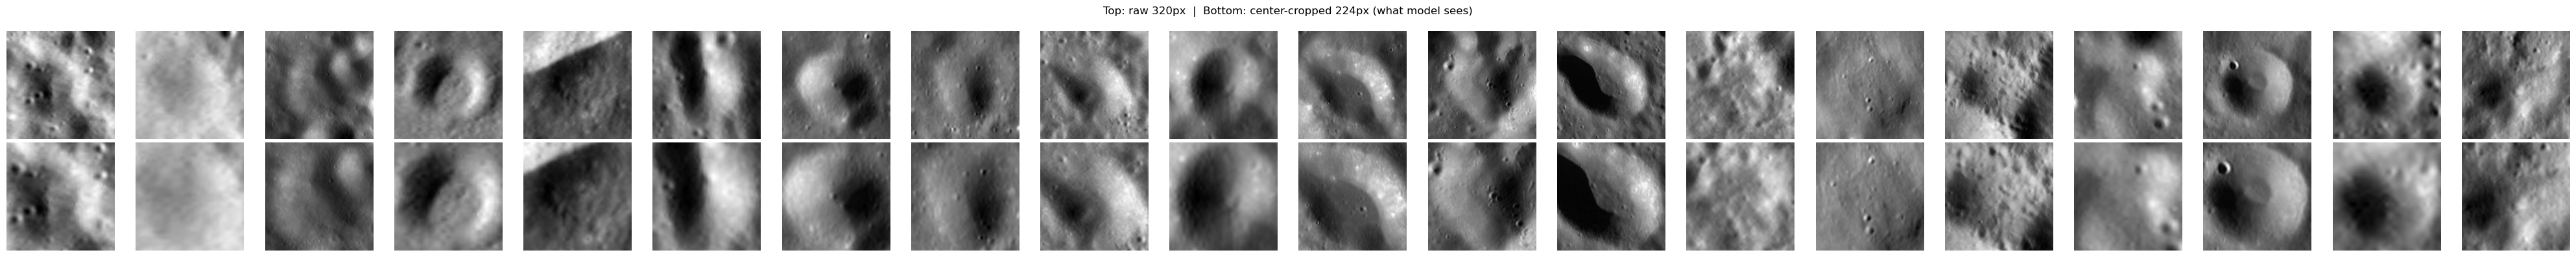

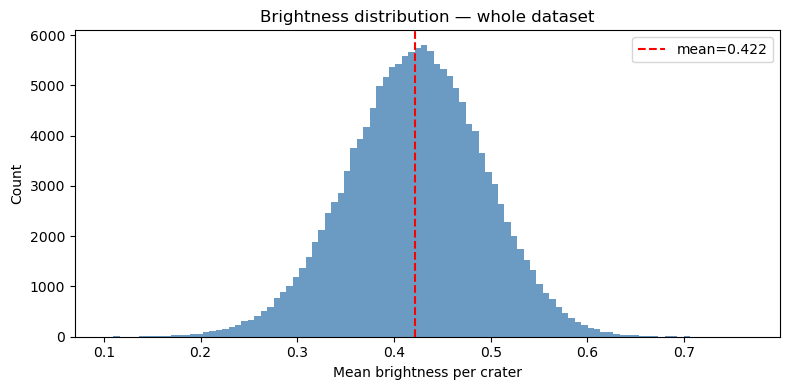

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch
import os

EXTRACT_SIZE = 320
INPUT_SIZE   = 224

path = 'data/processed_wac_100m_new/sigma/100/craters.dat'
file_size = os.path.getsize(path)
N = file_size // (EXTRACT_SIZE * EXTRACT_SIZE * 1 * 4)
craters = np.memmap(path, dtype=np.float32, mode='r', shape=(N, 1, EXTRACT_SIZE, EXTRACT_SIZE))
print(f"Total craters: {N}")

# ── 1. Value range ─────────────────────────────────────────────────────────
sample = np.array(craters[:1000, 0])
print(f"\n[1] Value range (first 1000)")
print(f"    Min: {sample.min():.4f}  Max: {sample.max():.4f}  Mean: {sample.mean():.4f}  Std: {sample.std():.4f}")
print(f"    → Expected: min≈0, max≈1 if normalized")

# ── 2. Check for bad tiles (blank / saturated / NaN) ──────────────────────
print(f"\n[2] Bad tile check (first 5000)")
batch = np.array(craters[:5000, 0])
blank     = (batch.std(axis=(1,2)) < 1e-4).sum()   # uniform/empty
saturated = (batch.max(axis=(1,2)) < 0.01).sum()   # all black
nan_count = np.isnan(batch).any(axis=(1,2)).sum()
print(f"    Blank (std<1e-4) : {blank}")
print(f"    All-black        : {saturated}")
print(f"    Contains NaN     : {nan_count}")

# ── 3. Random visual sample ────────────────────────────────────────────────
print(f"\n[3] Plotting 20 random craters (320px raw + 224px cropped)...")
rng = np.random.default_rng(42)
idx = rng.choice(N, size=20, replace=False)

fig, axes = plt.subplots(2, 20, figsize=(40, 4))
fig.suptitle("Top: raw 320px  |  Bottom: center-cropped 224px (what model sees)")
for j, i in enumerate(idx):
    raw  = craters[i, 0]
    crop = TF.center_crop(torch.from_numpy(np.array(raw)).unsqueeze(0), INPUT_SIZE).squeeze().numpy()
    axes[0, j].imshow(raw,  cmap='gray', vmin=0, vmax=1)
    axes[1, j].imshow(crop, cmap='gray', vmin=0, vmax=1)
    axes[0, j].axis('off')
    axes[1, j].axis('off')
plt.tight_layout()
plt.savefig('check_visual_sample.png', dpi=150)
print("    Saved → check_visual_sample.png")

# ── 4. Brightness distribution ────────────────────────────────────────────
print(f"\n[4] Brightness histogram (full dataset, batched)...")
batch_size = 2000
means = []
for i in range(0, N, batch_size):
    means.append(np.array(craters[i:i+batch_size, 0]).mean(axis=(1,2)))
means = np.concatenate(means)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(means, bins=100, color='steelblue', alpha=0.8)
ax.axvline(means.mean(), color='red', linestyle='--', label=f'mean={means.mean():.3f}')
ax.set_xlabel('Mean brightness per crater')
ax.set_ylabel('Count')
ax.set_title('Brightness distribution — whole dataset')
ax.legend()
plt.tight_layout()
plt.savefig('check_brightness_dist.png', dpi=150)

# ── 5. Outlier count ──────────────────────────────────────────────────────
print(f"\n[5] Outlier check (brightness)")
low  = (means < 0.05).sum()
high = (means > 0.95).sum()
print(f"    Very dark  (mean<0.05): {low}  ({100*low/N:.2f}%)")
print(f"    Very bright(mean>0.95): {high} ({100*high/N:.2f}%)")
print(f"\n    Saved → check_brightness_dist.png")

Total craters: 152103
Found 37116 outliers (24.4%)
Mild    (3-5)  : 32405
Medium  (5-10) : 4264
Extreme (>10)  : 447
Saved → outlier_samples.png


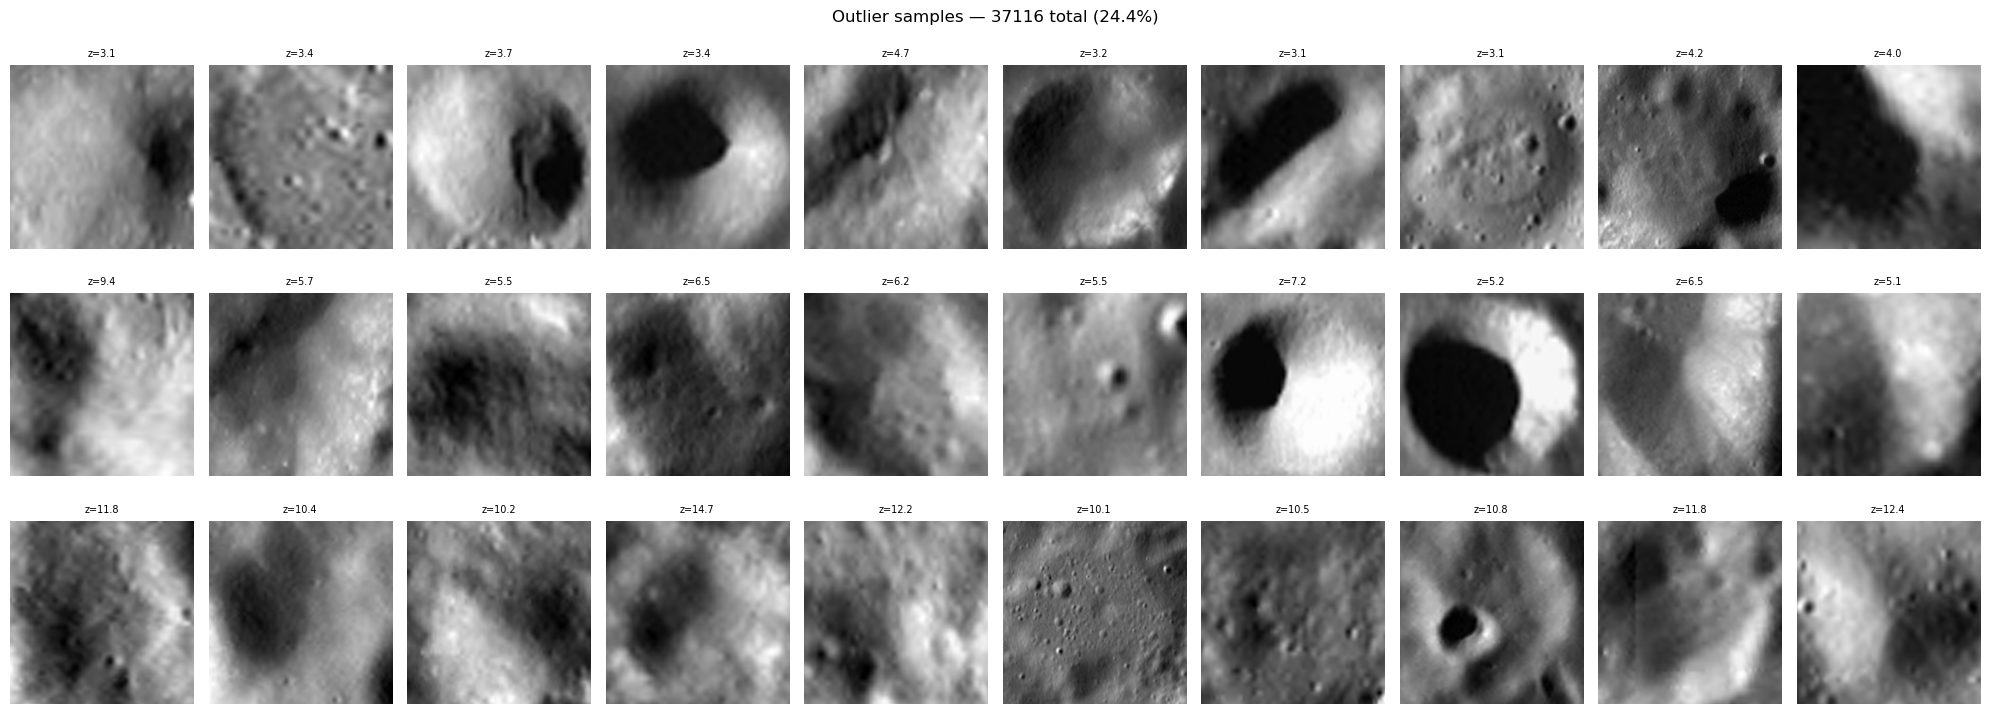

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch
import os
from scipy.stats import zscore

EXTRACT_SIZE = 320
INPUT_SIZE   = 224

path = 'data/processed_wac_100m_new/sigma/100/craters.dat'
file_size = os.path.getsize(path)
N = file_size // (EXTRACT_SIZE * EXTRACT_SIZE * 1 * 4)
craters = np.memmap(path, dtype=np.float32, mode='r', shape=(N, 1, EXTRACT_SIZE, EXTRACT_SIZE))
print(f"Total craters: {N}")

latents = np.load('logs/mae/processed_wac_100m_new/sigma/100/full_latent_vectors.npy')

z = np.abs(zscore(latents, axis=0)).max(axis=1)
outlier_indices = np.where(z > 3.0)[0]
print(f"Found {len(outlier_indices)} outliers ({100*len(outlier_indices)/N:.1f}%)")

rng = np.random.default_rng(42)

mild    = outlier_indices[z[outlier_indices] < 5]
medium  = outlier_indices[(z[outlier_indices] >= 5) & (z[outlier_indices] < 10)]
extreme = outlier_indices[z[outlier_indices] >= 10]

print(f"Mild    (3-5)  : {len(mild)}")
print(f"Medium  (5-10) : {len(medium)}")
print(f"Extreme (>10)  : {len(extreme)}")

n_cols = 10
groups = [(label, g) for label, g in
          [("Mild (z 3-5)", mild), ("Medium (z 5-10)", medium), ("Extreme (z>10)", extreme)]
          if len(g) > 0]

fig, axes = plt.subplots(len(groups), n_cols, figsize=(20, 2.5 * len(groups)))
if len(groups) == 1:
    axes = axes[np.newaxis, :]

for row, (label, group) in enumerate(groups):
    samples = rng.choice(group, size=min(n_cols, len(group)), replace=False)
    for col in range(n_cols):
        ax = axes[row, col]
        if col < len(samples):
            i    = samples[col]
            crop = TF.center_crop(
                torch.from_numpy(np.array(craters[i, 0])).unsqueeze(0), 224
            ).squeeze().numpy()
            ax.imshow(crop, cmap='gray')
            ax.set_title(f"z={z[i]:.1f}", fontsize=7)
        ax.axis('off')
    axes[row, 0].set_ylabel(label, fontsize=9)

plt.suptitle(f"Outlier samples — {len(outlier_indices)} total ({100*len(outlier_indices)/N:.1f}%)")
plt.tight_layout()
plt.savefig('outlier_samples.png', dpi=200)
print("Saved → outlier_samples.png")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import torchvision.transforms.functional as TF
import torch
import os

EXTRACT_SIZE = 320
INPUT_SIZE   = 224

# ── load ──────────────────────────────────────────────────────────────────
latents = np.load('logs/mae/processed_wac_100m_new/100/3.0_10.0_300_mask0.75/models/latent_vectors.npy')
path    = 'data/processed_wac_100m_new/sigma/100/craters.dat'
N       = os.path.getsize(path) // (EXTRACT_SIZE * EXTRACT_SIZE * 1 * 4)
craters = np.memmap(path, dtype=np.float32, mode='r', shape=(N, 1, EXTRACT_SIZE, EXTRACT_SIZE))
print(f"Latents shape: {latents.shape}")

# ── kmeans 100 (MiniBatch is much faster at this scale) ───────────────────
print("Fitting KMeans k=100...")
km = MiniBatchKMeans(n_clusters=100, random_state=42, batch_size=4096, n_init=5)
labels = km.fit_predict(latents)
print(f"Inertia: {km.inertia_:.2f}")

# cluster sizes — are they balanced or degenerate?
sizes = np.bincount(labels)
print(f"\nCluster sizes — min:{sizes.min()}  max:{sizes.max()}  mean:{sizes.mean():.0f}  std:{sizes.std():.0f}")
print(f"Empty clusters: {(sizes == 0).sum()}")
print(f"Tiny (<10):     {(sizes < 10).sum()}")

# ── PCA coloured by cluster ───────────────────────────────────────────────
pca    = PCA(n_components=2)
coords = pca.fit_transform(latents)
ev     = pca.explained_variance_ratio_
print(f"\nPCA variance explained: {ev.sum()*100:.1f}%  (PC1={ev[0]*100:.1f}%  PC2={ev[1]*100:.1f}%)")

# clip to 99.5th percentile to hide extreme outliers
p = np.percentile(coords, [0.5, 99.5], axis=0)
mask_plot = (
    (coords[:, 0] > p[0,0]) & (coords[:, 0] < p[1,0]) &
    (coords[:, 1] > p[0,1]) & (coords[:, 1] < p[1,1])
)

fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(coords[mask_plot, 0], coords[mask_plot, 1],
                c=labels[mask_plot], cmap='tab20', s=1, alpha=0.4)
ax.set_title(f"PCA — KMeans k=100  ({mask_plot.sum()} / {N} shown, outliers clipped)")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
plt.colorbar(sc, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('kmeans100_pca.png', dpi=200)
print("Saved → kmeans100_pca.png")

# ── cluster size histogram ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(100), sorted(sizes, reverse=True), color='steelblue')
ax.set_xlabel('Cluster (sorted by size)')
ax.set_ylabel('N craters')
ax.set_title('Cluster sizes — KMeans k=100')
ax.axhline(sizes.mean(), color='red', linestyle='--', label=f'mean={sizes.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('kmeans100_sizes.png', dpi=150)
print("Saved → kmeans100_sizes.png")

# ── show 5 random craters from 12 random clusters ─────────────────────────
rng          = np.random.default_rng(42)
show_clusters = rng.choice(100, size=12, replace=False)
n_cols       = 5

fig, axes = plt.subplots(12, n_cols, figsize=(n_cols*2, 12*2))
for row, k in enumerate(show_clusters):
    idx_k   = np.where(labels == k)[0]
    samples = rng.choice(idx_k, size=min(n_cols, len(idx_k)), replace=False)
    for col in range(n_cols):
        ax = axes[row, col]
        if col < len(samples):
            img = TF.center_crop(
                torch.from_numpy(np.array(craters[samples[col], 0])).unsqueeze(0),
                INPUT_SIZE
            ).squeeze().numpy()
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            if col == 0:
                ax.set_ylabel(f"k={k}\nn={len(idx_k)}", fontsize=8)
        ax.axis('off')

plt.suptitle("5 random craters from 12 random clusters (KMeans k=100)", fontsize=12)
plt.tight_layout()
plt.savefig('kmeans100_examples.png', dpi=150)
print("Saved → kmeans100_examples.png")